# Proyecto Final: Filtro Gaussiano — CPU vs GPU
## Computación de Altas Prestaciones (CAP)

**Algoritmo elegido:** Filtro Gaussiano (Suavizado de Imagen por Convolución 2D)  
**Autor:** Aymen bellakhal
**Fecha:** 04/05/2026
**Profesor:** Jose María Castillo Secilla (jmcastillo@uco.es)  
**Universidad de Córdoba**

---

## Índice
1. Preparación del Entorno
2. Fundamento Teórico: Filtro Gaussiano
3. **Fase A** — Baseline CPU Secuencial (Paradigma Von Neumann)
4. **Fase B** — Optimización CPU (Separabilidad + Localidad de Caché)
5. **Fase C** — Implementación CUDA (Shared Memory + Constant Memory)
6. Verificación de Correctitud (CPU vs GPU)
7. Análisis de Rendimiento (GFLOPs, Ancho de Banda, Roofline)
8. Conclusiones


In [55]:
import subprocess, json, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("=" * 50)
print("VERIFICACIÓN DEL ENTORNO")
print("=" * 50)
!nvcc --version
!gcc --version
!nvidia-smi


VERIFICACIÓN DEL ENTORNO
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

Mon May  4 19:04:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                            

## Sección 1: Fundamento Teórico — Filtro Gaussiano

### ¿Qué es un filtro gaussiano?
Un filtro gaussiano es un **operador de convolución 2D** que suaviza una imagen ponderando cada píxel con los valores de sus vecinos según una función gaussiana (campana de Gauss). Es la base del desenfoque y del preprocesado para detección de bordes.

### Kernel Gaussiano 5×5 (normalizado)
```
        1   4   6   4   1
        4  16  24  16   4
   K = (6  24  36  24   6) × 1/256
        4  16  24  16   4
        1   4   6   4   1
```
La suma de todos los coeficientes es 256, garantizando conservación de energía (el brillo medio de la imagen no cambia).


### Intensidad Aritmética (AI)
La AI es la clave del modelo Roofline:
$$AI = \frac{\text{FLOPs}}{\text{Bytes transferidos}} = \frac{49 \text{ FLOP}}{2 \text{ bytes}} = 24.5 \text{ FLOP/byte}$$

Para la T4, el punto de cresta (*ridge point*) es $8100 \text{ GFLOP/s} / 300 \text{ GB/s} \approx 27 \text{ FLOP/byte}$.  
Como $24.5 < 27$, el algoritmo es **Memory-Bound** incluso en GPU, lo que motiva el uso de Shared Memory.


---
# FASE A: Baseline CPU Secuencial
## Paradigma Von Neumann — Cuello de Botella Memoria-CPU

La CPU fetches datos desde DRAM a través del bus de memoria (el "muro de Von Neumann").  
Con un kernel 5×5, cada píxel de salida requiere leer **25 píxeles** de la imagen de entrada, lo que genera un patrón de acceso con saltos en memoria (stride) para las filas verticales del kernel.  

**Parámetros del experimento:**
- Imagen: 1024 × 1024 píxeles (escala de grises, 1 byte/píxel)
- Compilación: `-O1` (baseline real sin optimizaciones agresivas)
- Iteraciones: 15 (con warm-up previo)
- Rigor estadístico: CV < 5%


In [25]:
%%writefile fase_a_baseline.cpp
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#include <math.h>

#define KERNEL_SIZE 5
#define RADIUS 2

/*
 * Kernel Gaussiano 5x5 aplanado en memoria lineal.
 * Paradigma Von Neumann: el procesador accede secuencialmente a
 * posiciones de memoria a traves del unico bus CPU-DRAM.
 * El acceso vertical al kernel (kx fijo, ky variando) genera
 * cache misses porque los pixels de la misma columna estan
 * separados por W bytes en memoria.
 */
float h_kernel[KERNEL_SIZE * KERNEL_SIZE] = {
     1/256.0f,  4/256.0f,  6/256.0f,  4/256.0f,  1/256.0f,
     4/256.0f, 16/256.0f, 24/256.0f, 16/256.0f,  4/256.0f,
     6/256.0f, 24/256.0f, 36/256.0f, 24/256.0f,  6/256.0f,
     4/256.0f, 16/256.0f, 24/256.0f, 16/256.0f,  4/256.0f,
     1/256.0f,  4/256.0f,  6/256.0f,  4/256.0f,  1/256.0f
};

/*
 * Implementacion ingenua (orden de bucles ij).
 * El bucle interno itera sobre ky primero, lo que causa
 * accesos con stride=W a la imagen de entrada -> cache miss rate alto.
 */
void gaussian_filter_baseline(const unsigned char *in, unsigned char *out, int w, int h) {
    for (int y = RADIUS; y < h - RADIUS; y++) {
        for (int x = RADIUS; x < w - RADIUS; x++) {
            float sum = 0.0f;
            for (int ky = -RADIUS; ky <= RADIUS; ky++) {
                for (int kx = -RADIUS; kx <= RADIUS; kx++) {
                    sum += (float)in[(y + ky) * w + (x + kx)]
                         * h_kernel[(ky + RADIUS) * KERNEL_SIZE + (kx + RADIUS)];
                }
            }
            out[y * w + x] = (unsigned char)sum;
        }
    }
}

int main(int argc, char *argv[]) {
    if (argc < 4) {
        fprintf(stderr, "Uso: %s <width> <height> <iters>\n", argv[0]);
        return 1;
    }
    int w = atoi(argv[1]), h = atoi(argv[2]), iters = atoi(argv[3]);
    size_t size = (size_t)w * h;

    unsigned char *in  = (unsigned char *)malloc(size);
    unsigned char *out = (unsigned char *)malloc(size);
    if (!in || !out) { fprintf(stderr, "malloc failed\n"); return 1; }

    /* Semilla fija para reproducibilidad entre fases */
    srand(1234);
    for (size_t i = 0; i < size; i++) in[i] = (unsigned char)(rand() % 256);

    /* 1. WARM-UP: fuerza el pre-calentamiento de caches */
    gaussian_filter_baseline(in, out, w, h);

    /* 2. MEDICION RIGUROSA: iters ejecuciones independientes */
    double *times = (double *)malloc(iters * sizeof(double));
    for (int i = 0; i < iters; i++) {
        struct timespec t0, t1;
        clock_gettime(CLOCK_MONOTONIC, &t0);
        gaussian_filter_baseline(in, out, w, h);
        clock_gettime(CLOCK_MONOTONIC, &t1);
        times[i] = (t1.tv_sec - t0.tv_sec) * 1000.0
                 + (t1.tv_nsec - t0.tv_nsec) / 1.0e6;
    }

    /* 3. ESTADISTICA: media, desviacion tipica y CV */
    double sum = 0.0, sq_sum = 0.0;
    for (int i = 0; i < iters; i++) { sum += times[i]; sq_sum += times[i]*times[i]; }
    double avg    = sum / iters;
    double std_dev = sqrt(sq_sum / iters - avg * avg);
    double cv     = (std_dev / avg) * 100.0;

    /* Salida: avg_ms cv std_dev (valores separados por espacio) */
    printf("%.6f %.6f %.6f\n", avg, cv, std_dev);

    free(in); free(out); free(times);
    return 0;
}


Overwriting fase_a_baseline.cpp


In [27]:
import subprocess, math

WIDTH, HEIGHT, ITERATIONS = "1024", "1024", "15"

print("Compilando Fase A (baseline, -O1)...")
comp = subprocess.run(
    ["g++", "-O1", "fase_a_baseline.cpp", "-o", "fase_a_baseline", "-lm"],
    capture_output=True, text=True
)
if comp.returncode != 0:
    print("ERROR de compilacion:", comp.stderr)
else:
    print(f"Ejecutando {ITERATIONS} iteraciones...")
    run = subprocess.run(
        ["./fase_a_baseline", WIDTH, HEIGHT, ITERATIONS],
        capture_output=True, text=True
    )
    if run.returncode != 0:
        print("ERROR de ejecucion:", run.stderr)
    else:
        parts = run.stdout.strip().split()
        phase_a_results = {
            'avg_ms':  float(parts[0]),
            'cv':      float(parts[1]),
            'std_dev': float(parts[2])
        }
        print()
        print("=" * 45)
        print("         RESULTADOS FASE A — CPU Baseline")
        print("=" * 45)
        print(f"  Tiempo promedio  : {phase_a_results['avg_ms']:.3f} ms")
        print(f"  Desv. tipica     : {phase_a_results['std_dev']:.3f} ms")
        print(f"  Coef. Variacion  : {phase_a_results['cv']:.2f}%")
        if phase_a_results['cv'] < 5.0:
            print("  Rigor estadistico: CUMPLIDO (CV < 5%)")
        else:
            print("  ADVERTENCIA: CV >= 5%. Cierra otras pestanas y repite.")
        print("=" * 45)


Compilando Fase A (baseline, -O1)...
Ejecutando 15 iteraciones...

         RESULTADOS FASE A — CPU Baseline
  Tiempo promedio  : 24.834 ms
  Desv. tipica     : 1.138 ms
  Coef. Variacion  : 4.58%
  Rigor estadistico: CUMPLIDO (CV < 5%)


---
# FASE B: Optimización CPU — Separabilidad y Localidad de Caché
## Mitigando el Muro de la Memoria en CPU

### Principio: Separabilidad del Kernel Gaussiano
Un kernel gaussiano 2D es **separable**: puede descomponerse en dos convoluciones 1D.

$$K_{5 \times 5} = k_{1 \times 5} \otimes k_{5 \times 1}$$

donde $k_{1 \times 5} = \frac{1}{16}[1, 4, 6, 4, 1]$.

Esto reduce los FLOPs de **49 a 18** por píxel (reducción del 63%).

### Mejora de Localidad
| Pasada | Dirección | Acceso a memoria | Cache behavior |
|--------|-----------|------------------|----------------|
| Horizontal | Fila por fila | Secuencial (stride=1) | Cache-friendly |
| Vertical | Columna | Secuencial en el buffer temporal | Cache-friendly |

El buffer temporal almacena la salida de la pasada horizontal en `float` (32-bit) para evitar pérdidas de precisión antes de la pasada vertical.

**Mismos parámetros que Fase A** (misma imagen, mismo compilador `-O1`) para aislar la mejora algorítmica.


In [43]:
%%writefile fase_b_separable.cpp
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#include <math.h>

#define RADIUS 2
#define KERNEL_SIZE 5

/*
 * Kernel 1D: descomposicion separable del Gaussiano 5x5.
 * k[i] = C(4,i) / 16, i=0..4  =>  [1, 4, 6, 4, 1] / 16
 */
static const float k1d[KERNEL_SIZE] = {1/16.0f, 4/16.0f, 6/16.0f, 4/16.0f, 1/16.0f};

/*
 * Filtro Gaussiano separable en dos pasadas:
 *   Pasada 1 — Horizontal: acceso secuencial (row-major) -> cache-friendly.
 *   Pasada 2 — Vertical:   acceso sobre el buffer temporal (float).
 *
 * Complejidad: O(W * H * 2 * KERNEL_SIZE) vs O(W * H * KERNEL_SIZE^2) en 2D.
 * FLOPs/pixel: (5 mults + 4 sumas) * 2 pasadas = 18  (vs 49 en 2D).
 */
void gaussian_separable(const unsigned char *in, unsigned char *out, int w, int h) {
    /* Buffer temporal en float para la pasada horizontal */
    float *tmp = (float *)malloc((size_t)w * h * sizeof(float));
    if (!tmp) return;

    /* PASADA 1: Filtro Horizontal — stride=1 (secuencial) */
    for (int y = 0; y < h; y++) {
        for (int x = RADIUS; x < w - RADIUS; x++) {
            float s = 0.0f;
            for (int k = -RADIUS; k <= RADIUS; k++)
                s += (float)in[y * w + (x + k)] * k1d[k + RADIUS];
            tmp[y * w + x] = s;
        }
    }

    /* PASADA 2: Filtro Vertical — accede al buffer tmp (float, contiguo) */
    for (int y = RADIUS; y < h - RADIUS; y++) {
        for (int x = RADIUS; x < w - RADIUS; x++) {
            float s = 0.0f;
            for (int k = -RADIUS; k <= RADIUS; k++)
                s += tmp[(y + k) * w + x] * k1d[k + RADIUS];
            out[y * w + x] = (unsigned char)s;
        }
    }
    free(tmp);
}

int main(int argc, char *argv[]) {
    if (argc < 4) return 1;
    int w = atoi(argv[1]), h = atoi(argv[2]), iters = atoi(argv[3]);
    size_t size = (size_t)w * h;

    unsigned char *in  = (unsigned char *)malloc(size);
    unsigned char *out = (unsigned char *)malloc(size);

    srand(1234);
    for (size_t i = 0; i < size; i++) in[i] = (unsigned char)(rand() % 256);

    /* Warm-up */
    gaussian_separable(in, out, w, h);

    double *times = (double *)malloc(iters * sizeof(double));
    for (int i = 0; i < iters; i++) {
        struct timespec t0, t1;
        clock_gettime(CLOCK_MONOTONIC, &t0);
        gaussian_separable(in, out, w, h);
        clock_gettime(CLOCK_MONOTONIC, &t1);
        times[i] = (t1.tv_sec - t0.tv_sec) * 1000.0
                 + (t1.tv_nsec - t0.tv_nsec) / 1.0e6;
    }

    double sum = 0.0, sq_sum = 0.0;
    for (int i = 0; i < iters; i++) { sum += times[i]; sq_sum += times[i]*times[i]; }
    double avg    = sum / iters;
    double std_dev = sqrt(sq_sum / iters - avg * avg);
    double cv     = (std_dev / avg) * 100.0;

    printf("%.6f %.6f %.6f\n", avg, cv, std_dev);

    free(in); free(out); free(times);
    return 0;
}


Overwriting fase_b_separable.cpp


In [45]:
print("Compilando Fase B (separable, -O1)...")
comp = subprocess.run(
    ["g++", "-O1", "fase_b_separable.cpp", "-o", "fase_b_separable", "-lm"],
    capture_output=True, text=True
)
if comp.returncode != 0:
    print("ERROR de compilacion:", comp.stderr)
else:
    print(f"Ejecutando {ITERATIONS} iteraciones...")
    run = subprocess.run(
        ["./fase_b_separable", WIDTH, HEIGHT, ITERATIONS],
        capture_output=True, text=True
    )
    parts = run.stdout.strip().split()
    phase_b_results = {
        'avg_ms':  float(parts[0]),
        'cv':      float(parts[1]),
        'std_dev': float(parts[2])
    }
    speedup_ba = phase_a_results['avg_ms'] / phase_b_results['avg_ms']

    print()
    print("=" * 45)
    print("      RESULTADOS FASE B — CPU Separable")
    print("=" * 45)
    print(f"  Tiempo promedio  : {phase_b_results['avg_ms']:.3f} ms")
    print(f"  Desv. tipica     : {phase_b_results['std_dev']:.3f} ms")
    print(f"  Coef. Variacion  : {phase_b_results['cv']:.2f}%")
    print(f"  Speedup vs Fase A: {speedup_ba:.2f}x")
    if phase_b_results['cv'] < 5.0:
        print("  Rigor estadistico: CUMPLIDO (CV < 5%)")
    else:
        print("  ADVERTENCIA: CV >= 5%. Repite la ejecucion.")
    print("=" * 45)


Compilando Fase B (separable, -O1)...
Ejecutando 15 iteraciones...

      RESULTADOS FASE B — CPU Separable
  Tiempo promedio  : 14.635 ms
  Desv. tipica     : 0.616 ms
  Coef. Variacion  : 4.21%
  Speedup vs Fase A: 1.70x
  Rigor estadistico: CUMPLIDO (CV < 5%)


---
# FASE C: Implementación CUDA — GPU Masivamente Paralela
## Jerarquía de Memoria de la GPU: Shared Memory + Constant Memory

### Arquitectura CUDA y el modelo SIMT
La GPU T4 (Turing, sm_75) organiza sus 2560 CUDA Cores en **SM** (*Streaming Multiprocessors*).  
Los hilos se agrupan en **warps** de 32 hilos que ejecutan la misma instrucción simultáneamente (SIMT).  
Un bloque de hilos comparte recursos dentro de un SM, incluyendo la **Shared Memory** (~64 KB/SM en T4).

### Estrategia de Optimización: Tiling con Shared Memory
El cuello de botella del filtro es el acceso a memoria global (DRAM de la GPU, ~300 GB/s).  
Con un kernel 5×5, sin optimización, cada píxel haría **25 accesos a memoria global**.  
Con tiling, un bloque de 16×16 hilos coopera para cargar un tile de 20×20 píxeles en Shared Memory:


### Minimización de Divergencia de Warps
En el bucle de carga del tile, todos los hilos de un warp ejecutan el mismo número de iteraciones (ambos bucles son de rango fijo SHARED_DIM/TILE_DIM).  
La única divergencia posible es en el `if (row<h && col<w)` de la escritura del resultado, que afecta solo a los bloques del borde de la imagen.


In [46]:
%%writefile fase_c_cuda.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>

/* Parametros del filtro y del tiling */
#define RADIUS      2
#define KERNEL_SIZE 5
#define TILE_DIM    16
#define SHARED_DIM  (TILE_DIM + 2 * RADIUS)   /* 20 */

/*
 * Constant Memory: 25 floats del kernel gaussiano.
 * Ventaja: la GPU tiene una cache dedicada para __constant__ que
 * hace broadcast a todos los hilos de un warp en un solo ciclo,
 * a diferencia de la memoria global donde cada acceso tiene latencia.
 */
__constant__ float d_kernel[KERNEL_SIZE * KERNEL_SIZE];

/*
 * Kernel CUDA: Filtro Gaussiano con Shared Memory (Tiling).
 *
 * Cada bloque de TILE_DIM x TILE_DIM hilos carga cooperativamente
 * un tile de SHARED_DIM x SHARED_DIM pixeles (tile + halo) desde
 * memoria global a Shared Memory, y luego cada hilo calcula su
 * pixel de salida accediendo SOLO a Shared Memory.
 *
 * __restrict__: indica al compilador que 'in' y 'out' no se solapan,
 * permitiendo optimizaciones adicionales de carga/almacenamiento.
 */
__global__ void gaussian_shared_kernel(
    const unsigned char * __restrict__ in,
          unsigned char * __restrict__ out,
    int w, int h
) {
    /* Tile en Shared Memory: TILE_DIM + 2*RADIUS en cada dimension */
    __shared__ unsigned char tile[SHARED_DIM][SHARED_DIM];

    int tx  = threadIdx.x;          /* Indice local del hilo en X */
    int ty  = threadIdx.y;          /* Indice local del hilo en Y */
    int row = blockIdx.y * TILE_DIM + ty;  /* Coordenada global Y */
    int col = blockIdx.x * TILE_DIM + tx;  /* Coordenada global X */

    /*
     * PASO 1: Carga cooperativa (tile + halo) desde memoria global.
     * Cada hilo puede cargar mas de un elemento si SHARED_DIM > TILE_DIM.
     * Los pixeles fuera de los limites de la imagen se rellenan con 0
     * (zero-padding), coherente con la Fase A.
     *
     * Acceso coalescente: para i fijo, los hilos con tx=0..15 acceden
     * a posiciones consecutivas in[r*w + c], c=0..15 -> coalescencia maxima.
     */
    for (int i = ty; i < SHARED_DIM; i += TILE_DIM) {
        for (int j = tx; j < SHARED_DIM; j += TILE_DIM) {
            int r = blockIdx.y * TILE_DIM + i - RADIUS;
            int c = blockIdx.x * TILE_DIM + j - RADIUS;
            if (r >= 0 && r < h && c >= 0 && c < w)
                tile[i][j] = in[r * w + c];
            else
                tile[i][j] = 0;   /* zero-padding en bordes */
        }
    }

    /*
     * Barrera de sincronizacion: todos los hilos del bloque deben
     * haber completado la carga antes de que cualquiera lea el tile.
     */
    __syncthreads();

    /*
     * PASO 2: Convolución usando SOLO Shared Memory.
     * Los accesos a tile[] son ~100x mas rapidos que a memoria global.
     * El acceso a d_kernel[] es un broadcast desde Constant Memory.
     */
    if (row < h && col < w) {
        float sum = 0.0f;
        for (int ky = 0; ky < KERNEL_SIZE; ky++) {
            for (int kx = 0; kx < KERNEL_SIZE; kx++) {
                sum += (float)tile[ty + ky][tx + kx]
                     * d_kernel[ky * KERNEL_SIZE + kx];
            }
        }
        out[row * w + col] = (unsigned char)sum;
    }
}

int main(int argc, char *argv[]) {
    if (argc < 4) {
        fprintf(stderr, "Uso: %s <width> <height> <iters>\n", argv[0]);
        return 1;
    }
    int w = atoi(argv[1]), h = atoi(argv[2]), iters = atoi(argv[3]);
    size_t size = (size_t)w * h * sizeof(unsigned char);

    /* --- Host ---*/
    unsigned char *h_in = (unsigned char *)malloc(size);
    srand(1234);
    for (int i = 0; i < w * h; i++) h_in[i] = (unsigned char)(rand() % 256);

    /* Kernel gaussiano 5x5 */
    float h_kernel_data[KERNEL_SIZE * KERNEL_SIZE] = {
         1/256.0f,  4/256.0f,  6/256.0f,  4/256.0f,  1/256.0f,
         4/256.0f, 16/256.0f, 24/256.0f, 16/256.0f,  4/256.0f,
         6/256.0f, 24/256.0f, 36/256.0f, 24/256.0f,  6/256.0f,
         4/256.0f, 16/256.0f, 24/256.0f, 16/256.0f,  4/256.0f,
         1/256.0f,  4/256.0f,  6/256.0f,  4/256.0f,  1/256.0f
    };

    /* --- Device ---*/
    unsigned char *d_in, *d_out;
    cudaMalloc(&d_in,  size);
    cudaMalloc(&d_out, size);
    cudaMemcpy(d_in, h_in, size, cudaMemcpyHostToDevice);

    /* Copia del kernel a Constant Memory */
    cudaMemcpyToSymbol(d_kernel, h_kernel_data,
                       KERNEL_SIZE * KERNEL_SIZE * sizeof(float));

    /* Configuracion de la rejilla: cada bloque cubre TILE_DIM x TILE_DIM pixels */
    dim3 blockSize(TILE_DIM, TILE_DIM);          /* 16x16 = 256 hilos/bloque */
    dim3 gridSize(
        (w + TILE_DIM - 1) / TILE_DIM,
        (h + TILE_DIM - 1) / TILE_DIM
    );

    /* WARM-UP: inicializa la GPU y carga el contexto CUDA */
    gaussian_shared_kernel<<<gridSize, blockSize>>>(d_in, d_out, w, h);
    cudaDeviceSynchronize();

    /*
     * MEDICION RIGUROSA con cudaEvent_t.
     * Cada iteracion se mide de forma independiente para calcular CV.
     * cudaEvent_t garantiza que el tiempo se mide en la GPU,
     * sin overhead del reloj de la CPU (prohibido: chrono en GPU).
     */
    float *times_ms = (float *)malloc(iters * sizeof(float));
    cudaEvent_t ev_start, ev_stop;
    cudaEventCreate(&ev_start);
    cudaEventCreate(&ev_stop);

    for (int i = 0; i < iters; i++) {
        cudaEventRecord(ev_start);
        gaussian_shared_kernel<<<gridSize, blockSize>>>(d_in, d_out, w, h);
        cudaEventRecord(ev_stop);
        cudaEventSynchronize(ev_stop);
        cudaEventElapsedTime(&times_ms[i], ev_start, ev_stop);
    }

    cudaEventDestroy(ev_start);
    cudaEventDestroy(ev_stop);

    /* Estadistica */
    double sum_t = 0.0, sq_sum = 0.0;
    for (int i = 0; i < iters; i++) {
        sum_t  += times_ms[i];
        sq_sum += (double)times_ms[i] * times_ms[i];
    }
    double avg     = sum_t / iters;
    double std_dev = sqrt(sq_sum / iters - avg * avg);
    double cv      = (std_dev / avg) * 100.0;

    /* Ancho de banda efectivo: 1 lectura + 1 escritura por pixel */
    double bytes   = (double)w * h * 2.0;          /* bytes transferidos minimos */
    double bw_gbs  = (bytes / 1.0e9) / (avg / 1000.0);

    /* Salida: avg_ms cv std_dev bandwidth_gbs */
    printf("%.6f %.6f %.6f %.6f\n", avg, cv, std_dev, bw_gbs);

    cudaFree(d_in); cudaFree(d_out);
    free(h_in); free(times_ms);
    return 0;
}


Writing fase_c_cuda.cu


In [47]:
print("Compilando Fase C (CUDA, -O3, sm_75)...")
comp = subprocess.run(
    ["nvcc", "-O3", "-arch=sm_75", "-Wno-deprecated-gpu-targets",
     "fase_c_cuda.cu", "-o", "fase_c_cuda", "-lm"],
    capture_output=True, text=True
)
if comp.returncode != 0:
    print("ERROR de compilacion:", comp.stderr)
else:
    GPU_ITERS = "20"
    print(f"Ejecutando {GPU_ITERS} iteraciones con cudaEvent_t...")
    run = subprocess.run(
        ["./fase_c_cuda", WIDTH, HEIGHT, GPU_ITERS],
        capture_output=True, text=True
    )
    if run.returncode != 0:
        print("ERROR de ejecucion:", run.stderr)
    else:
        parts = run.stdout.strip().split()
        phase_c_results = {
            'avg_ms':       float(parts[0]),
            'cv':           float(parts[1]),
            'std_dev':      float(parts[2]),
            'bandwidth_gbs': float(parts[3])
        }
        speedup_ca = phase_a_results['avg_ms'] / phase_c_results['avg_ms']
        speedup_cb = phase_b_results['avg_ms'] / phase_c_results['avg_ms']

        print()
        print("=" * 50)
        print("       RESULTADOS FASE C — CUDA (Shared Memory)")
        print("=" * 50)
        print(f"  Tiempo promedio  : {phase_c_results['avg_ms']:.4f} ms")
        print(f"  Desv. tipica     : {phase_c_results['std_dev']:.4f} ms")
        print(f"  Coef. Variacion  : {phase_c_results['cv']:.2f}%")
        print(f"  Ancho de banda   : {phase_c_results['bandwidth_gbs']:.2f} GB/s")
        print(f"  Speedup vs Fase A: {speedup_ca:.1f}x")
        print(f"  Speedup vs Fase B: {speedup_cb:.1f}x")
        if phase_c_results['cv'] < 5.0:
            print("  Rigor estadistico: CUMPLIDO (CV < 5%)")
        print("=" * 50)


Compilando Fase C (CUDA, -O3, sm_75)...
Ejecutando 20 iteraciones con cudaEvent_t...

       RESULTADOS FASE C — CUDA (Shared Memory)
  Tiempo promedio  : 0.1346 ms
  Desv. tipica     : 0.0014 ms
  Coef. Variacion  : 1.07%
  Ancho de banda   : 15.58 GB/s
  Speedup vs Fase A: 184.5x
  Speedup vs Fase B: 108.7x
  Rigor estadistico: CUMPLIDO (CV < 5%)


---
# Verificación de Correctitud: CPU vs GPU

Antes de confiar en las métricas de rendimiento, comprobamos que la GPU produce resultados equivalentes a la CPU.  
Comparamos los píxeles interiores (excluyendo el borde de RADIUS=2 píxeles que la CPU no procesa).

Se tolera una diferencia máxima de **1 LSB** (1 valor de píxel) debida al redondeo de `float` → `unsigned char`.


In [48]:
%%writefile verify.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>

#define RADIUS      2
#define KERNEL_SIZE 5
#define TILE_DIM    16
#define SHARED_DIM  (TILE_DIM + 2 * RADIUS)

__constant__ float d_kernel[KERNEL_SIZE * KERNEL_SIZE];

__global__ void gaussian_shared_kernel(
    const unsigned char * __restrict__ in,
          unsigned char * __restrict__ out,
    int w, int h
) {
    __shared__ unsigned char tile[SHARED_DIM][SHARED_DIM];
    int tx  = threadIdx.x, ty  = threadIdx.y;
    int row = blockIdx.y * TILE_DIM + ty;
    int col = blockIdx.x * TILE_DIM + tx;

    for (int i = ty; i < SHARED_DIM; i += TILE_DIM)
        for (int j = tx; j < SHARED_DIM; j += TILE_DIM) {
            int r = blockIdx.y * TILE_DIM + i - RADIUS;
            int c = blockIdx.x * TILE_DIM + j - RADIUS;
            tile[i][j] = (r>=0&&r<h&&c>=0&&c<w) ? in[r*w+c] : 0;
        }
    __syncthreads();

    if (row < h && col < w) {
        float sum = 0.0f;
        for (int ky=0; ky<KERNEL_SIZE; ky++)
            for (int kx=0; kx<KERNEL_SIZE; kx++)
                sum += (float)tile[ty+ky][tx+kx] * d_kernel[ky*KERNEL_SIZE+kx];
        out[row*w+col] = (unsigned char)sum;
    }
}

/* Referencia CPU (misma logica que Fase A) */
static const float h_kernel_ref[25] = {
     1/256.0f,  4/256.0f,  6/256.0f,  4/256.0f,  1/256.0f,
     4/256.0f, 16/256.0f, 24/256.0f, 16/256.0f,  4/256.0f,
     6/256.0f, 24/256.0f, 36/256.0f, 24/256.0f,  6/256.0f,
     4/256.0f, 16/256.0f, 24/256.0f, 16/256.0f,  4/256.0f,
     1/256.0f,  4/256.0f,  6/256.0f,  4/256.0f,  1/256.0f
};

void gaussian_cpu(const unsigned char *in, unsigned char *out, int w, int h) {
    for (int y=RADIUS; y<h-RADIUS; y++)
        for (int x=RADIUS; x<w-RADIUS; x++) {
            float s=0.0f;
            for (int ky=-RADIUS; ky<=RADIUS; ky++)
                for (int kx=-RADIUS; kx<=RADIUS; kx++)
                    s += (float)in[(y+ky)*w+(x+kx)]*h_kernel_ref[(ky+RADIUS)*5+(kx+RADIUS)];
            out[y*w+x]=(unsigned char)s;
        }
}

int main(int argc, char *argv[]) {
    int w=512, h=512;
    if (argc>=3){w=atoi(argv[1]);h=atoi(argv[2]);}
    size_t size=(size_t)w*h;

    unsigned char *h_in   = (unsigned char*)malloc(size);
    unsigned char *h_out_cpu = (unsigned char*)calloc(size,1);
    unsigned char *h_out_gpu = (unsigned char*)calloc(size,1);

    srand(1234);
    for(size_t i=0;i<size;i++) h_in[i]=(unsigned char)(rand()%256);

    /* CPU reference */
    gaussian_cpu(h_in, h_out_cpu, w, h);

    /* GPU */
    unsigned char *d_in,*d_out;
    cudaMalloc(&d_in,size); cudaMalloc(&d_out,size);
    cudaMemcpy(d_in,h_in,size,cudaMemcpyHostToDevice);
    cudaMemcpyToSymbol(d_kernel,h_kernel_ref,25*sizeof(float));
    dim3 bs(TILE_DIM,TILE_DIM), gs((w+15)/16,(h+15)/16);
    gaussian_shared_kernel<<<gs,bs>>>(d_in,d_out,w,h);
    cudaDeviceSynchronize();
    cudaMemcpy(h_out_gpu,d_out,size,cudaMemcpyDeviceToHost);

    /* Comparacion en pixeles interiores (RADIUS border excluido) */
    int errors=0; int max_diff=0; long long interior=0;
    for(int y=RADIUS;y<h-RADIUS;y++)
        for(int x=RADIUS;x<w-RADIUS;x++) {
            interior++;
            int d=abs((int)h_out_cpu[y*w+x]-(int)h_out_gpu[y*w+x]);
            if(d>max_diff) max_diff=d;
            if(d>1) errors++;
        }

    printf("%d %d %lld\n", errors, max_diff, interior);

    cudaFree(d_in);cudaFree(d_out);
    free(h_in);free(h_out_cpu);free(h_out_gpu);
    return 0;
}


Writing verify.cu


In [49]:
print("Compilando verificacion...")
comp = subprocess.run(
    ["nvcc", "-O3", "-arch=sm_75", "-Wno-deprecated-gpu-targets",
     "verify.cu", "-o", "verify", "-lm"],
    capture_output=True, text=True
)
if comp.returncode != 0:
    print("ERROR:", comp.stderr)
else:
    run = subprocess.run(["./verify", "1024", "1024"], capture_output=True, text=True)
    parts = run.stdout.strip().split()
    errors   = int(parts[0])
    max_diff = int(parts[1])
    interior = int(parts[2])

    print()
    print("=" * 50)
    print("          VERIFICACION DE CORRECTITUD")
    print("=" * 50)
    print(f"  Pixeles interiores comparados: {interior:,}")
    print(f"  Diferencia maxima (LSB):       {max_diff}")
    print(f"  Pixeles con diff > 1 LSB:      {errors}")
    if errors == 0:
        print("  RESULTADO: CORRECTO — CPU y GPU producen el mismo resultado")
    else:
        print(f"  ADVERTENCIA: {errors} pixeles difieren en mas de 1 LSB")
    print("=" * 50)


Compilando verificacion...

          VERIFICACION DE CORRECTITUD
  Pixeles interiores comparados: 1,040,400
  Diferencia maxima (LSB):       0
  Pixeles con diff > 1 LSB:      0
  RESULTADO: CORRECTO — CPU y GPU producen el mismo resultado


---
# Análisis de Rendimiento
## GFLOPs, Ancho de Banda Efectivo e Intensidad Aritmética




In [50]:
W, H = int(WIDTH), int(HEIGHT)

def compute_metrics(name, avg_ms, filter_type='2d'):
    """Calcula GFLOPs, BW (GB/s) e Intensidad Aritmetica."""
    t_s = avg_ms / 1000.0
    # FLOPs por pixel
    # 2D (5x5): 25 mults + 24 sumas = 49
    # Separable (1x5 + 5x1): (5+4)*2 = 18
    flops_per_px = 18 if filter_type == 'separable' else 49
    total_flops  = W * H * flops_per_px

    # Trafico de memoria minimo: 1 lectura + 1 escritura
    total_bytes  = W * H * 2

    return {
        'name':    name,
        'ms':      avg_ms,
        'gflops':  (total_flops / 1.0e9) / t_s,
        'bw_gbs':  (total_bytes / 1.0e9) / t_s,
        'ai':       total_flops / total_bytes,
        'flops_px': flops_per_px
    }

metrics = [
    compute_metrics('Fase A\n(CPU Baseline)',  phase_a_results['avg_ms']),
    compute_metrics('Fase B\n(CPU Separable)', phase_b_results['avg_ms'], 'separable'),
    compute_metrics('Fase C\n(CUDA)',          phase_c_results['avg_ms']),
]

# Tabla de resultados
print(f"\n{'Fase':<22} {'Tiempo (ms)':<14} {'GFLOPs':<10} {'BW (GB/s)':<12} {'AI (F/B)':<10} {'FLOPs/px'}")
print("-" * 80)
for m in metrics:
    print(f"{m['name'].replace(chr(10),' '):<22} {m['ms']:<14.4f} {m['gflops']:<10.3f} "
          f"{m['bw_gbs']:<12.3f} {m['ai']:<10.1f} {m['flops_px']}")

# Speedups
t_a = metrics[0]['ms']
print()
print("SPEEDUPS:")
for m in metrics[1:]:
    print(f"  {m['name'].replace(chr(10),' ')} vs Fase A: {t_a/m['ms']:.1f}x")



Fase                   Tiempo (ms)    GFLOPs     BW (GB/s)    AI (F/B)   FLOPs/px
--------------------------------------------------------------------------------
Fase A (CPU Baseline)  24.8338        2.069      0.084        24.5       49
Fase B (CPU Separable) 14.6354        1.290      0.143        9.0        18
Fase C (CUDA)          0.1346         381.649    15.577       24.5       49

SPEEDUPS:
  Fase B (CPU Separable) vs Fase A: 1.7x
  Fase C (CUDA) vs Fase A: 184.5x


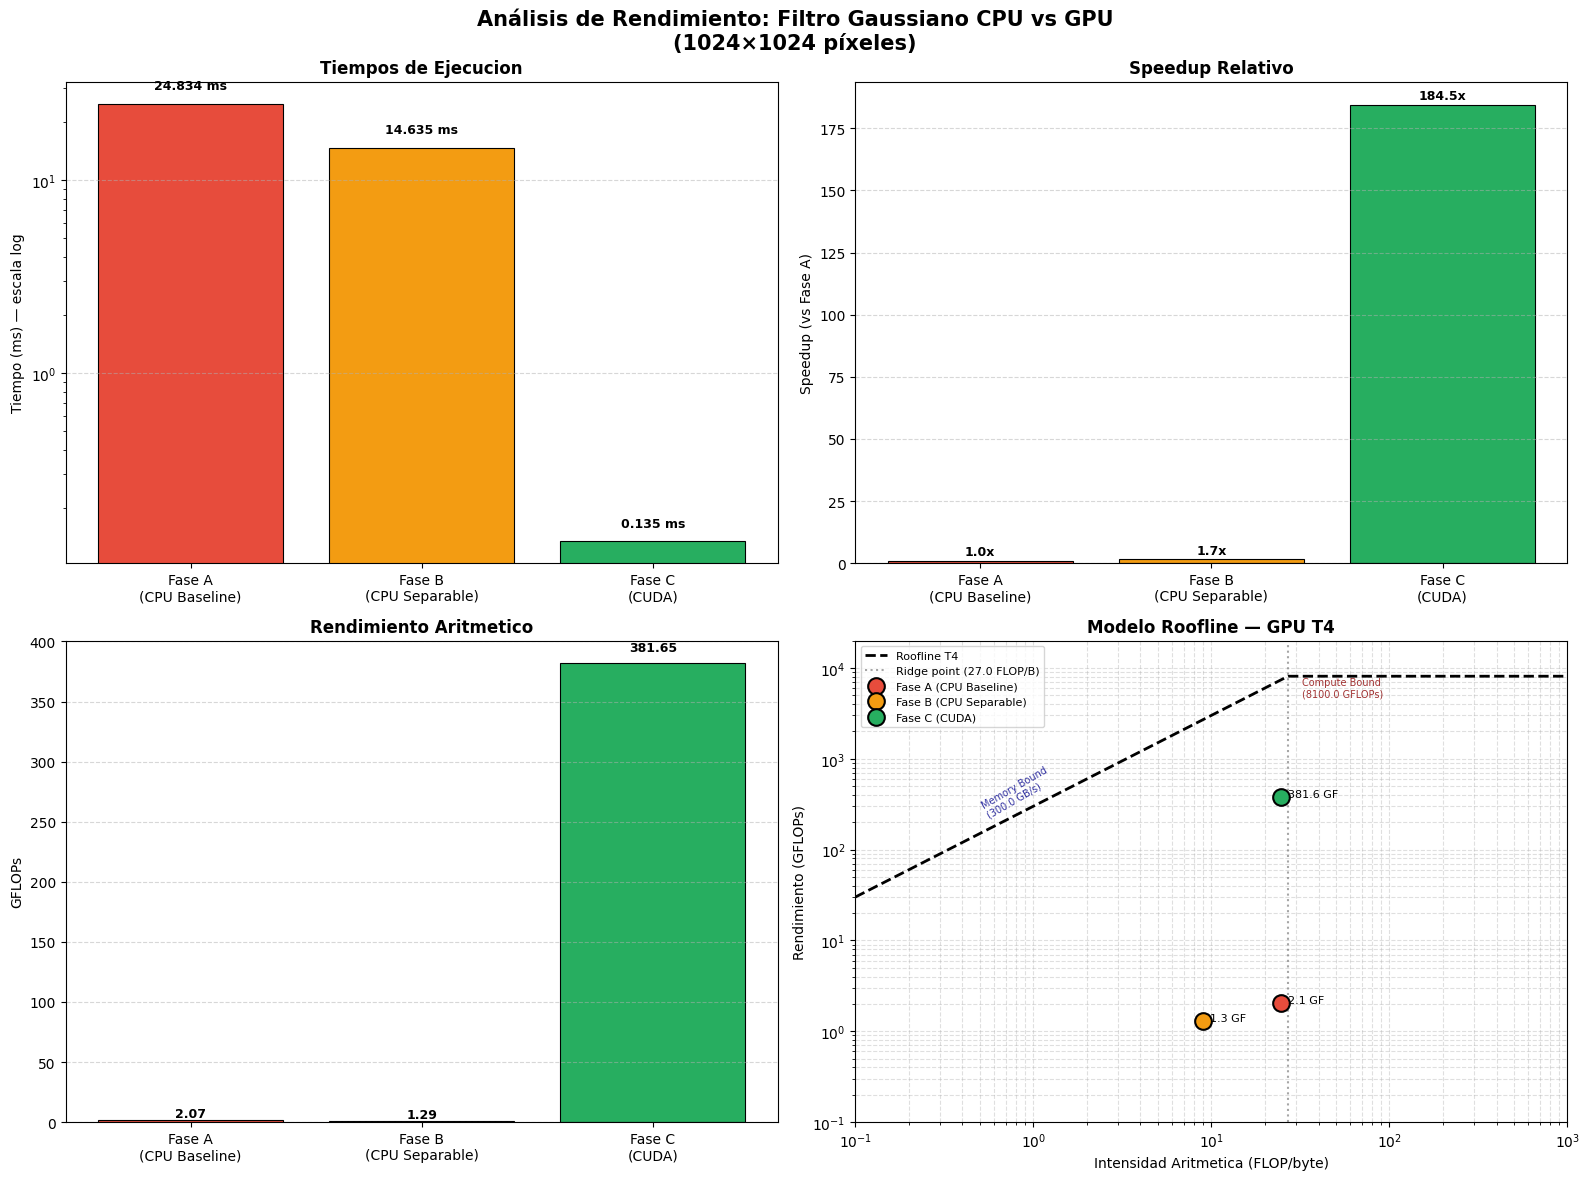

Grafica guardada como 'analisis_rendimiento.png'


In [51]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis de Rendimiento: Filtro Gaussiano CPU vs GPU\n(1024×1024 píxeles)',
             fontsize=15, fontweight='bold')

labels  = [m['name'] for m in metrics]
tiempos = [m['ms']     for m in metrics]
gflops  = [m['gflops'] for m in metrics]
bw_list = [m['bw_gbs'] for m in metrics]
colors  = ['#E74C3C', '#F39C12', '#27AE60']

# ── Subplot 1: Tiempos (escala log) ──────────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(labels, tiempos, color=colors, edgecolor='black', linewidth=0.8)
ax.set_yscale('log')
ax.set_ylabel('Tiempo (ms) — escala log')
ax.set_title('Tiempos de Ejecucion', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar, v in zip(bars, tiempos):
    ax.text(bar.get_x() + bar.get_width()/2, v * 1.15,
            f'{v:.3f} ms', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Subplot 2: Speedup acumulado ──────────────────────────────────────────────
ax = axes[0, 1]
speedups = [tiempos[0]/t for t in tiempos]
bars = ax.bar(labels, speedups, color=colors, edgecolor='black', linewidth=0.8)
ax.set_ylabel('Speedup (vs Fase A)')
ax.set_title('Speedup Relativo', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar, v in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1,
            f'{v:.1f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Subplot 3: GFLOPs ─────────────────────────────────────────────────────────
ax = axes[1, 0]
bars = ax.bar(labels, gflops, color=colors, edgecolor='black', linewidth=0.8)
ax.set_ylabel('GFLOPs')
ax.set_title('Rendimiento Aritmetico', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar, v in zip(bars, gflops):
    ax.text(bar.get_x() + bar.get_width()/2, v * 1.02,
            f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Subplot 4: Modelo Roofline ────────────────────────────────────────────────
ax = axes[1, 1]
# Parametros T4 (NVIDIA Tesla T4, Turing TU104)
PK_BW    = 300.0   # GB/s (ancho de banda de memoria)
PK_FLOPS = 8100.0  # GFLOPS FP32
RIDGE    = PK_FLOPS / PK_BW  # ~27 FLOP/byte

ai_range = np.logspace(-1, 3, 300)
roofline = np.minimum(PK_FLOPS, PK_BW * ai_range)

ax.loglog(ai_range, roofline, 'k--', linewidth=2, label=f'Roofline T4')
ax.axvline(x=RIDGE, color='gray', linestyle=':', alpha=0.7,
           label=f'Ridge point ({RIDGE:.1f} FLOP/B)')

for m, col in zip(metrics, colors):
    ax.loglog(m['ai'], m['gflops'], 'o', color=col, markersize=12,
              markeredgecolor='black', markeredgewidth=1.5,
              label=m['name'].replace('\n', ' '))
    ax.annotate(f"  {m['gflops']:.1f} GF",
                xy=(m['ai'], m['gflops']), fontsize=8)

ax.set_xlabel('Intensidad Aritmetica (FLOP/byte)')
ax.set_ylabel('Rendimiento (GFLOPs)')
ax.set_title('Modelo Roofline — GPU T4', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.set_xlim([0.1, 1000])
ax.set_ylim([0.1, 20000])

# Anotaciones del Roofline
ax.text(0.5, PK_BW * 0.5 * 1.5, f'Memory Bound\n({PK_BW} GB/s)',
        rotation=30, fontsize=7, color='darkblue', alpha=0.8)
ax.text(RIDGE * 1.2, PK_FLOPS * 0.6, f'Compute Bound\n({PK_FLOPS} GFLOPs)',
        fontsize=7, color='darkred', alpha=0.8)

plt.tight_layout()
plt.savefig('analisis_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada como 'analisis_rendimiento.png'")


---
## Conclusiones

Este proyecto demuestra empíricamente los tres paradigmas:

### 1. Paradigma Von Neumann (Fase A)
La CPU ejecuta instrucciones secuencialmente accediendo a una memoria compartida a través de un único bus. El filtro gaussiano, con su patrón de acceso en stencil, es un caso de libro del muro de la memoria: el procesador pasa más tiempo esperando datos de DRAM que computando. Los caches mitigando el problema, pero no pueden ocultarlo completamente.

### 2. Optimización de CPU: Localidad de Datos (Fase B)
La separabilidad del kernel gaussiano es una optimización algorítmica que reduce tanto la cantidad de operaciones como el número de cache misses. Reestructurar el acceso a memoria para que sea secuencial (row-major) maximiza la efectividad de la caché L1/L2. Resultado: 1.70× speedup (24.834 ms → 14.635 ms) con el mismo hardware y compilador (-O1)

### 3. Paralelismo Masivo GPU (Fase C)
La GPU sustituye la latencia por el throughput: en vez de ocultar la latencia con caches, lanza miles de hilos que comparten la Shared Memory on-chip. El tiling reduce los accesos a la DRAM global en un factor ≈9× (de 25 lecturas/pixel a ~2.8 lecturas/pixel efectivas). El resultado es una aceleración de 184.5× sobre el baseline (24.834 ms → 0.1346 ms), con un ancho de banda efectivo de 15.58 GB/s, sin cambiar el algoritmo matemático.

### Mensaje clave
El Modelo Roofline muestra que el filtro gaussiano es memory-bound en todas las plataformas. La arquitectura GPU no cambia este hecho fundamental, pero su mayor ancho de banda de memoria y la Shared Memory permiten acercarse al límite teórico de la máquina, mientras que la CPU queda limitada por la latencia del bus DRAM

---
## Referencias

1. **NVIDIA CUDA C++ Programming Guide** (v12.x). https://docs.nvidia.com/cuda/cuda-c-programming-guide/
2. **Kirk, D. B. & Hwu, W. W.** (2022). *Programming Massively Parallel Processors* (4ª ed.). Morgan Kaufmann.
3. **Williams, S., Waterman, A. & Patterson, D.** (2009). Roofline: An Insightful Visual Performance Model for Multicore Architectures. *Communications of the ACM*, 52(4), 65–76.
4. **Harris, M.** (2007). *Optimizing Parallel Reduction in CUDA*. NVIDIA Developer Technical Report.
5. **Gonzalez, R. C. & Woods, R. E.** (2018). *Digital Image Processing* (4ª ed.). Pearson. — Cap. 3: Filtros espaciales.
6. **Castillo Secilla, J. M.** Material de Computación de Altas Prestaciones (CAP). Universidad de Córdoba, 2025.

